In [1]:
from deap import tools, creator, base, algorithms, benchmarks
import pymop
from math import factorial
from numpy import random
from meamt_core import generate_dtlz3_front_random, calculate_igd_plus
import numpy
from deap.benchmarks.tools import hypervolume
import numpy as np

PROBLEM = "dtlz2"
NOBJ = 4
K = 10
NDIM = NOBJ + K - 1
P = 12
BOUND_LOW, BOUND_UP = 0.0, 1.0
pareto_real = generate_dtlz3_front_random(NOBJ, 1000)

In [2]:
MU = 800
NGEN = 300
CXPB = 1.0
MUTPB = 1.0

ref_points_hv = [1.1] * NOBJ
ref_points = tools.uniform_reference_points(NOBJ, P)


In [3]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,) * NOBJ)
creator.create("Individual", list, fitness=creator.FitnessMin)

def uniform(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox = base.Toolbox()
toolbox.register("attr_float", uniform, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", benchmarks.dtlz2, obj=NOBJ)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=30.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA3, ref_points=ref_points)

In [4]:
def main(seed=None):
    random.seed(seed)

    # Initialize statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean, axis=0)
    stats.register("std", numpy.std, axis=0)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "std", "min", "avg", "max", "hypervolume", "igd_plus"

    pop = toolbox.population(n=MU)

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Compile statistics about the population
    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process
    for gen in range(1, NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Select the next generation population from parents and offspring
        pop = toolbox.select(pop + offspring, MU)

        # Compile statistics about the new population
        record = stats.compile(pop)
        pop_comp = pop[:(int)(MU/(1 << NOBJ))]
        hv_val = hypervolume(pop_comp, ref_points_hv)
        approx_front = np.array([ind.fitness.values for ind in pop])
        approx_front_comp = approx_front[:(int)(MU/(1 << NOBJ))]
        igd_plus_val = calculate_igd_plus(pareto_real, approx_front_comp)
        logbook.record(gen=gen, evals=len(invalid_ind), hypervolume=hv_val,igd_plus=igd_plus_val, **record)
        print(logbook.stream)

    return pop, logbook

In [5]:
pop, logbook = main()

gen	evals	std                                          	min                                                          	avg                                          	max                                          	hypervolume	igd_plus
0  	800  	[0.43659704 0.45134769 0.54892364 0.6102008 ]	[2.04958802e-06 3.46360182e-05 3.35853529e-04 2.97407907e-03]	[0.45797201 0.48017136 0.76559207 1.15128522]	[1.93712262 1.93531757 2.44562144 2.40370129]	           	        
1  	800  	[0.5117384  0.51401988 0.5340299  0.53925334]	[2.04958802e-06 3.46360182e-05 3.35853529e-04 1.00733133e-03]	[0.53281816 0.55789655 0.74662938 0.84500363]	[2.01598044 2.14992438 2.33615573 2.0952445 ]	0.0497417  	0.552767
2  	800  	[0.51098236 0.52273108 0.52056765 0.50733218]	[1.97120660e-06 3.30977539e-05 3.35853529e-04 7.98767088e-04]	[0.54139931 0.57555838 0.69894302 0.69201105]	[2.17007622 2.13726658 2.08956729 2.08050191]	0.0997248  	0.474043
3  	800  	[0.51309749 0.51283966 0.50346544 0.48120274]	[1.97120660e-06 3.08

[0.3960643779308851, 0.0009431460983801987, 0.00043586542097283115, 0.49221753437092103, 0.49365762100185023, 0.5010746090634595, 0.49010340759993676, 0.4908771077451093, 0.5163878806383416, 0.4684053385077897, 0.5132061996530587, 0.5001458636345189, 0.4935167703977227]
[0.84548065509341, 0.7043082825464057, 0.00028545914417513717, 0.5098942506304466, 0.523626457442243, 0.5125749970189162, 0.49743072468310257, 0.4951370443796276, 0.5051410880487606, 0.5607980486369585, 0.49867803092807145, 0.5299159522375545, 0.5188207528585462]
[0.25055220959166996, 0.17951423113861617, 0.9999886753984861, 0.4816633599030875, 0.46672424703397214, 0.5261233838397519, 0.5016563924190726, 0.5000801484777961, 0.5746296574681753, 0.49437981649780904, 0.4953143882649062, 0.5061425701343035, 0.48879588470443225]
[0.2820904459325525, 0.0012465716026034412, 0.2910256239029154, 0.45653735990404853, 0.4926398335742442, 0.511668625664653, 0.4998688051212161, 0.49890030446004585, 0.49801191872044337, 0.50415020623

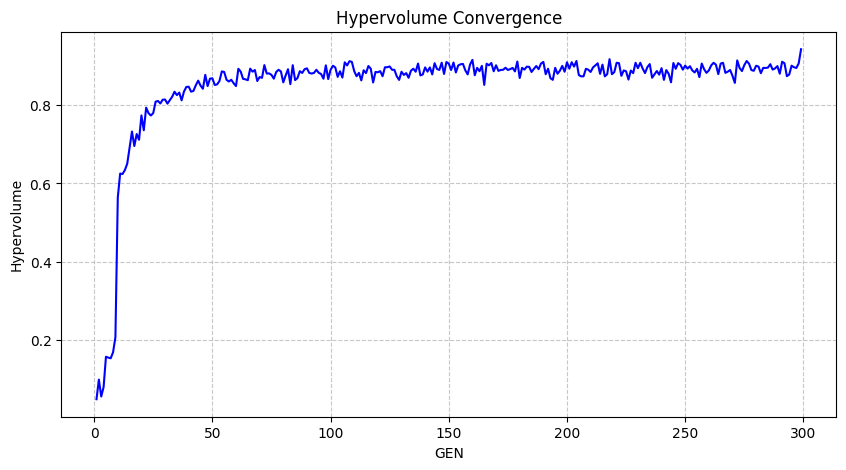

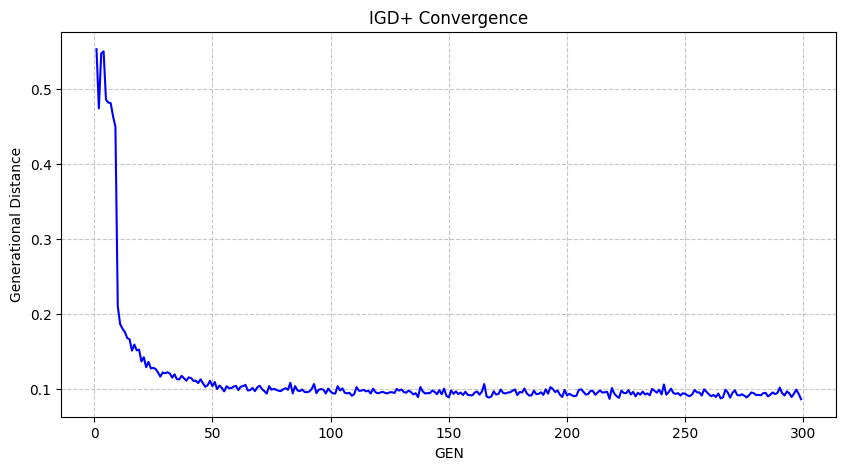

In [6]:
import matplotlib.pyplot as plt


for ind in pop:
   print(ind)

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()